# Exploratory Data Analysis and Predictive Modeling of Housing Dataset

This notebook performs exploratory data analysis and predictive modeling of the housing dataset. The following are covered
- Distributions (SalePrice, features)
- Correlation heatmap
- Scatter plots + insights
- Identify outliers
- Feature Engineering
- Predictive modeling using Linear Regression, Decision Tree and Random Forest
- Evaluation and assessment using RMSE and R2 along with feature importance and residual analysis

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings(action="ignore")

The first step is to import the libraries needed for the analysis. **NumPy** and **Pandas** handle numerical operations and data manipulation respectively. **Matplotlib** and **Seaborn** are used for all visualisations throughout this notebook.

## 2. Load Dataset

In [2]:
df = pd.read_csv("dataset/housing.csv")

The dataset is loaded from a local CSV file into a Pandas DataFrame. This is the California Housing dataset, which contains block-level housing information collected from the 1990 US Census.

## 3. Preliminary Data Exploration

Before any visualisation, a preliminary inspection is carried out to understand the structure, data types, summary statistics, and data quality of the dataset.

### 3.1. View the first five rows

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The dataset contains **10 columns**. The first five rows reveal a mix of continuous numerical features such as `longitude` and `median_income`, and one categorical feature `ocean_proximity`. The target variable is `median_house_value`. The early rows all belong to the `NEAR BAY` category, suggesting the data may be geographically ordered.

### 3.2. View dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


The dataset contains **20,640 rows** and **10 columns**. Key observations:

- **9 features** are of type `float64` and one (`ocean_proximity`) is of type `object`
- `total_bedrooms` is the **only column with missing values**, having 207 null entries
- All other columns are fully complete

### 3.3 Statistical information

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


The descriptive statistics reveal several important characteristics:

- **`median_house_value`** ranges from `$14,999` to `$500,001`. The maximum of exactly `$500,001` is suspicious and likely represents a **hard cap** applied during data collection
- **`median_income`** is expressed in tens of thousands (e.g. 3.87 ≈ \$38,700)
- **`total_rooms`, `total_bedrooms`, `population`, and `households`** all have very large standard deviations relative to their means, indicating heavily skewed distributions with extreme values

### 3.4 Check for duplicates

In [6]:
df.duplicated().sum()

0

No duplicate rows were found. Every row represents a unique census block group, so no cleaning is needed on this front.

## 4. Data visualisation

In [7]:
sns.set_style("darkgrid")

### 4.1 Distribution of Target Variable (median_house_value)

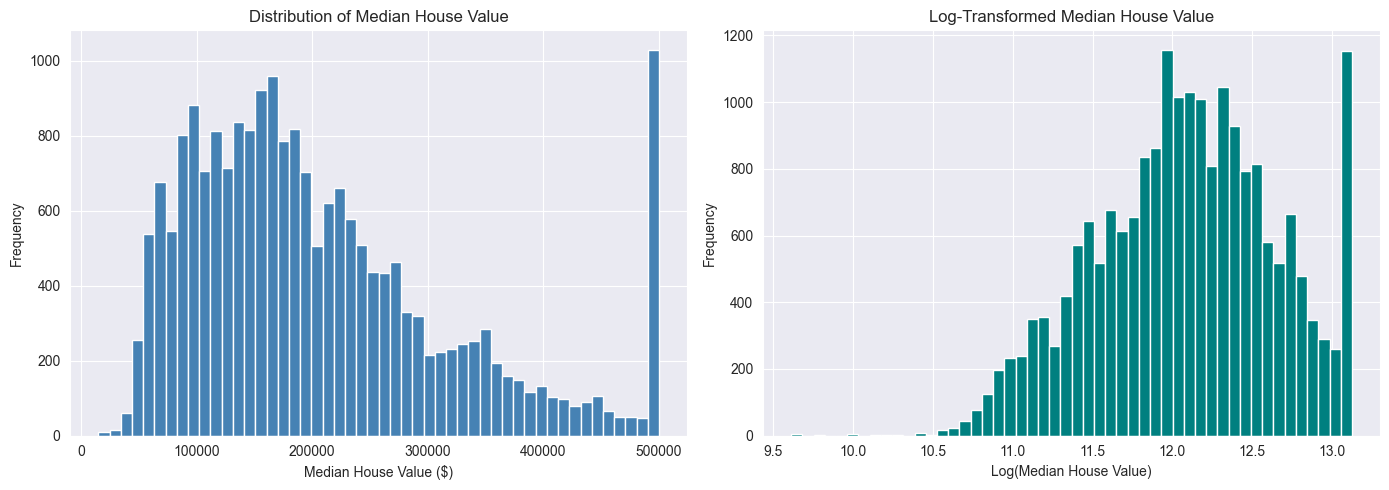

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df["median_house_value"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Median House Value")
axes[0].set_xlabel("Median House Value ($)")
axes[0].set_ylabel("Frequency")

# Log-transformed distribution to check for skewness
axes[1].hist(np.log1p(df["median_house_value"]), bins=50, color="teal", edgecolor="white")
axes[1].set_title("Log-Transformed Median House Value")
axes[1].set_xlabel("Log(Median House Value)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [9]:
# Print skewness of the target variable
print(f"Skewness of median_house_value: {df['median_house_value'].skew():.4f}")

Skewness of median_house_value: 0.9778


Two histograms are plotted: the raw distribution and a log-transformed version to assess skewness.

- The raw distribution is **right-skewed** with a skewness of **0.9778**, meaning most house values cluster in the lower-to-mid range with a long tail towards higher values
- There is a **prominent spike at $500,001**, the data cap identified earlier. Nearly 5% of records hit this ceiling, meaning the true upper-end distribution is artificially truncated
- The log-transformed distribution is more symmetric but the same spike persists, confirming the cap is a structural data artefact
- This cap should be acknowledged as a **limitation** in the paper, as it may distort the performance of regression models at the upper end

### 4.2 Distributions of Numerical Features

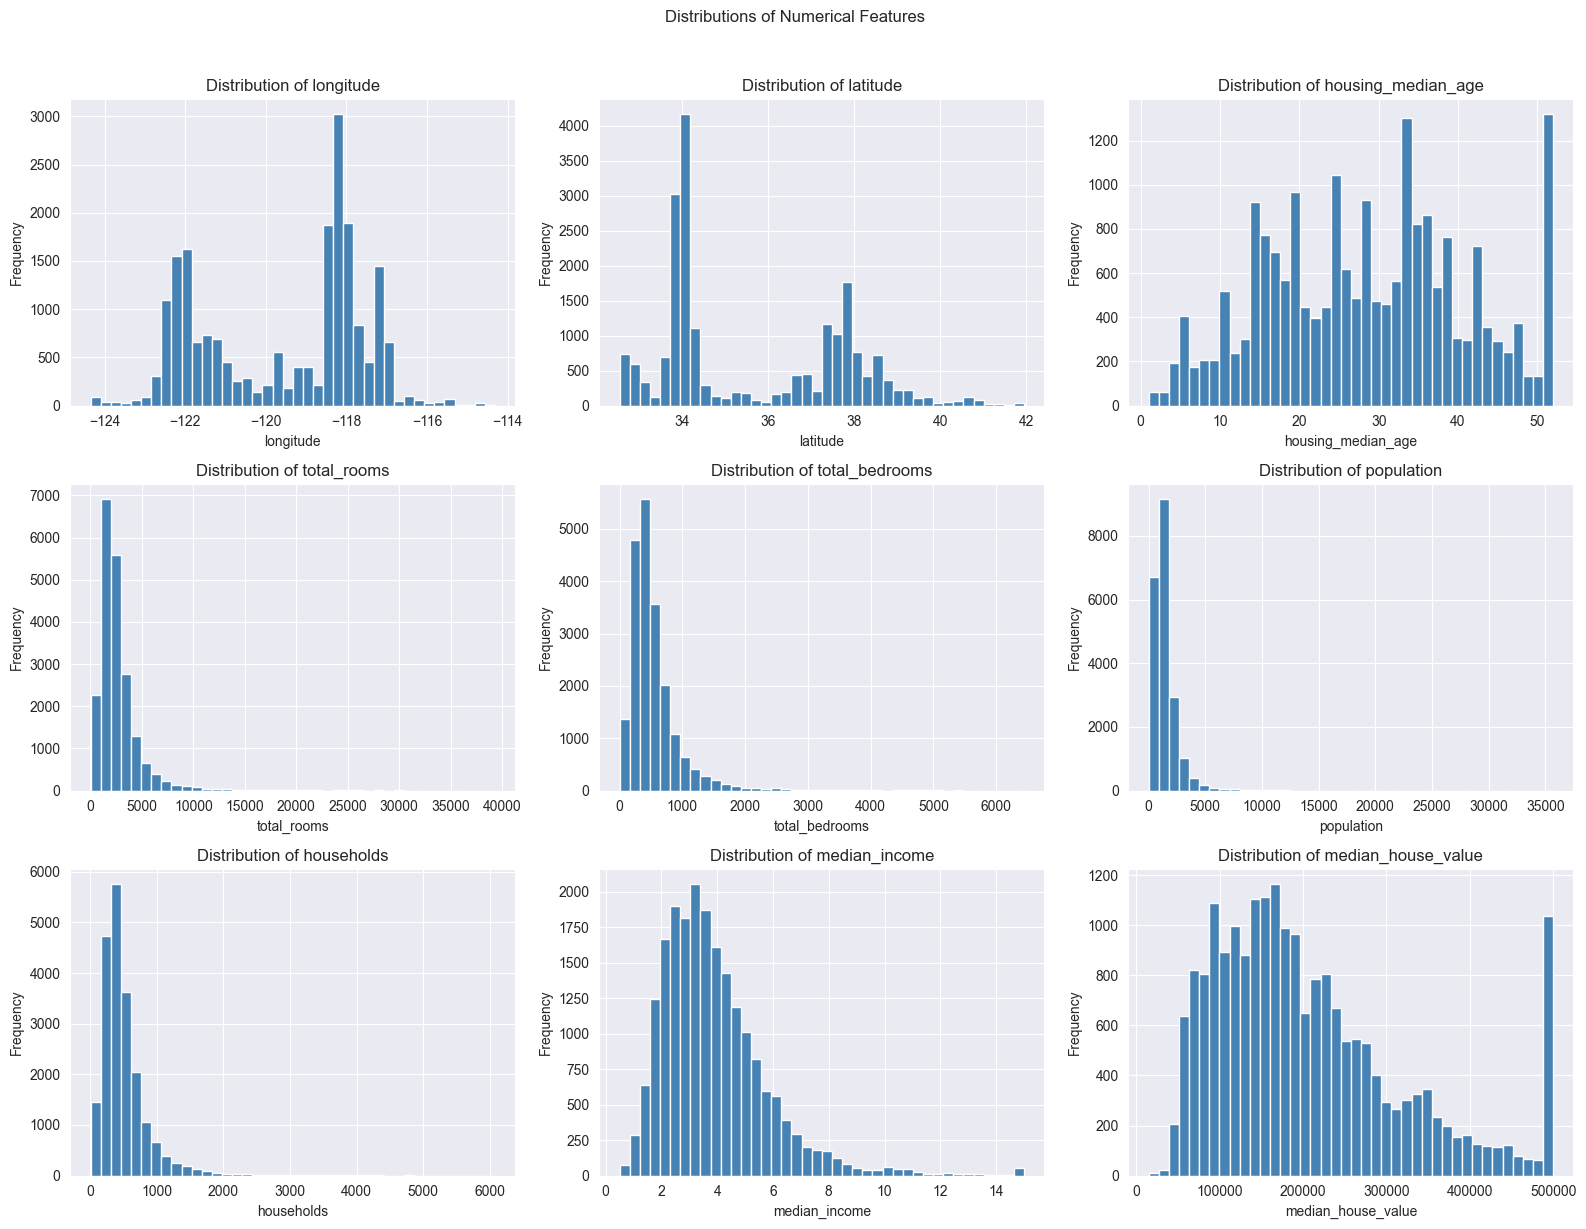

In [10]:
# Select only numeric columns for distribution plots
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

A 3×3 grid of histograms shows the distribution of every numerical feature.

- **`longitude` and `latitude`**: Both show **bimodal distributions** with two peaks corresponding to the two main population centres in California: the San Francisco Bay Area and Los Angeles
- **`housing_median_age`**: Fairly uniform with a noticeable spike at 52, likely another data cap for older properties
- **`total_rooms`, `total_bedrooms`, `population`, `households`**: All **heavily right-skewed**, with most block groups having moderate values and a small number of very large ones pulling the tail
- **`median_income`**: Roughly bell-shaped and slightly right-skewed, centred around `$30,000` to `$40,000`
- **`median_house_value`**: Right-skewed with the hard cap spike at $500,001, as discussed above

### 4.3 Distribution of Categorical Feature (ocean_proximity)

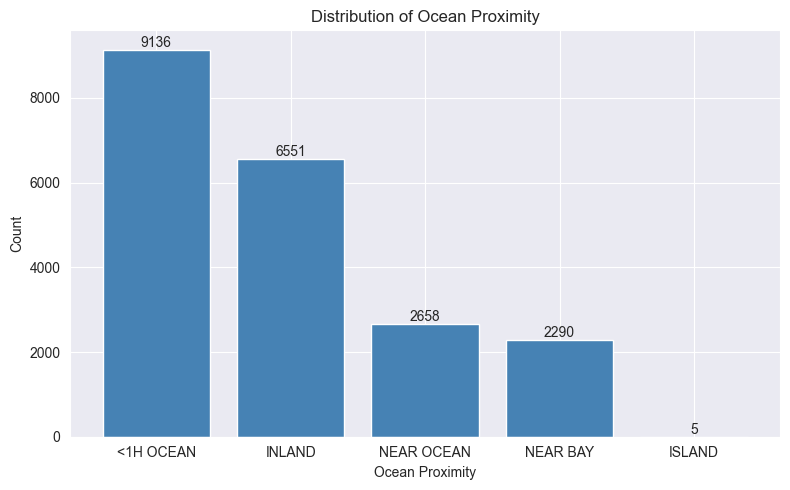

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

# Count occurrences of each category
ocean_counts = df["ocean_proximity"].value_counts()

bars = ax.bar(ocean_counts.index, ocean_counts.values, color="steelblue", edgecolor="white")

ax.set_title("Distribution of Ocean Proximity")
ax.set_xlabel("Ocean Proximity")
ax.set_ylabel("Count")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [12]:
print(df["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


The bar chart shows the frequency of each ocean proximity category.

- The dataset is **heavily imbalanced**: `1H OCEAN` accounts for nearly **44%** of all records
- `INLAND` is the second largest group at around **32%**
- `ISLAND` has only **5 records**, making it a negligible category that may need to be removed or treated separately during modelling
- The distribution reflects California's geography, where the most densely populated areas are concentrated near the coast

### 4.4 Correlation Heatmap

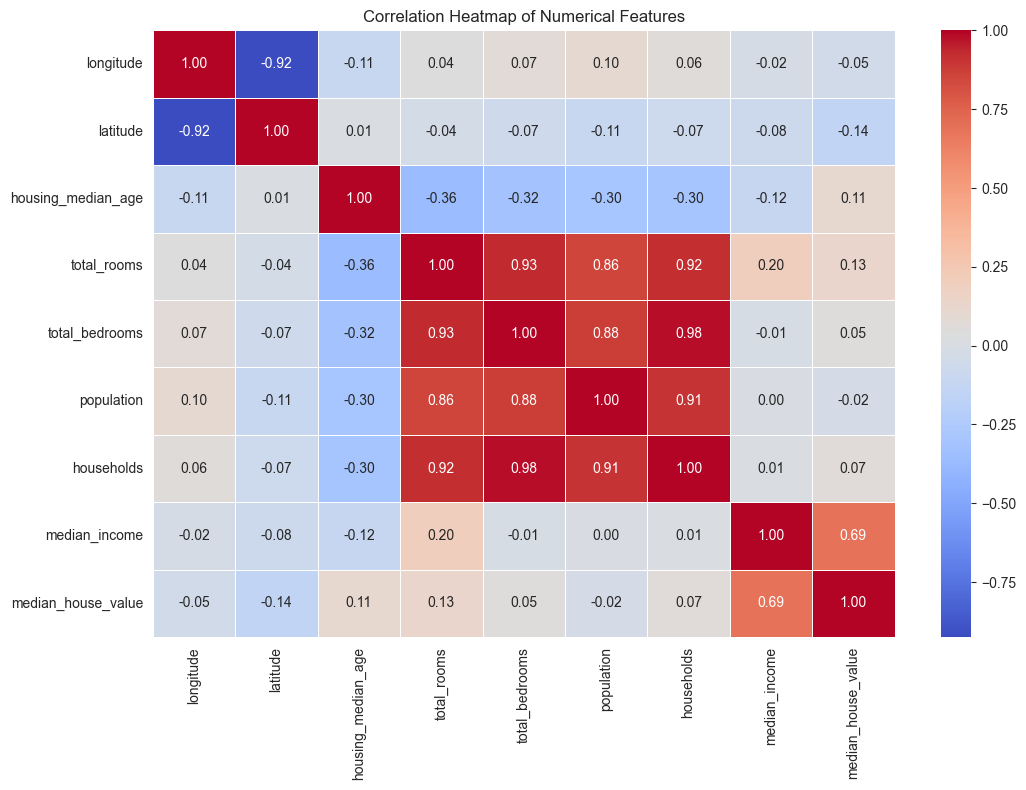

In [13]:
fig, ax = plt.subplots(figsize=(11, 8))

# Compute correlation matrix for numeric features only
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [14]:
# Print top correlations with the target variable
print("Correlations with median_house_value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

Correlations with median_house_value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


The heatmap shows pairwise Pearson correlations between all numerical features.

- **`median_income`** is by far the strongest predictor of `median_house_value` with a correlation of **0.69**
- **`total_rooms`, `total_bedrooms`, `population`, and `households`** form a tightly correlated cluster with values between **0.86 and 0.98**. This **multicollinearity** should be addressed during feature engineering, for example by creating per-household ratios
- Most other features have only weak correlations with the target, reinforcing that `median_income` carries the dominant signal

### 4.5 Scatter Plots: Key Features vs median_house_value

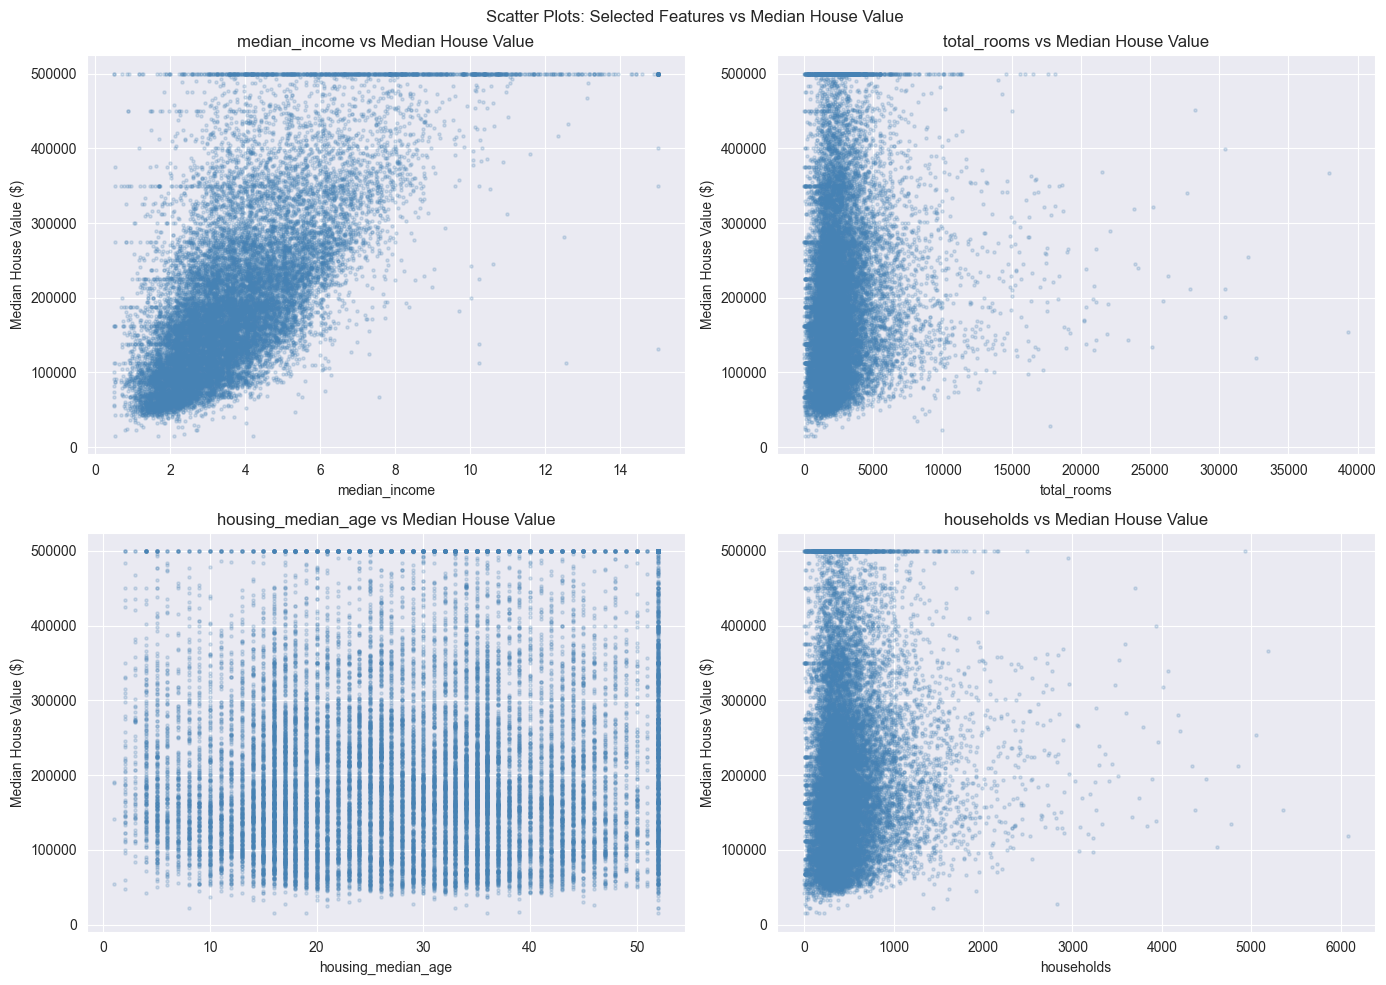

In [15]:
# Features most correlated with the target based on the heatmap
scatter_features = ["median_income", "total_rooms", "housing_median_age", "households"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df["median_house_value"], alpha=0.2, color="steelblue", s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Median House Value ($)")
    axes[i].set_title(f"{col} vs Median House Value")

plt.suptitle("Scatter Plots: Selected Features vs Median House Value")
plt.tight_layout()
plt.show()

Scatter plots are generated for the four features most correlated with `median_house_value`.

- **`median_income`**: Clear **positive upward trend**, though non-linear. Visible horizontal bands at `$350,000` and `$500,001` are data capping artefacts
- **`total_rooms`**: No clear linear trend. Most values cluster at low room counts with no consistent relationship to house value
- **`housing_median_age`**: **Vertical striping** due to integer storage. No meaningful trend visible across any age band
- **`households`**: Similar to `total_rooms`, data is concentrated at low counts with no discernible pattern

### 4.6 Geographic Distribution of House Values

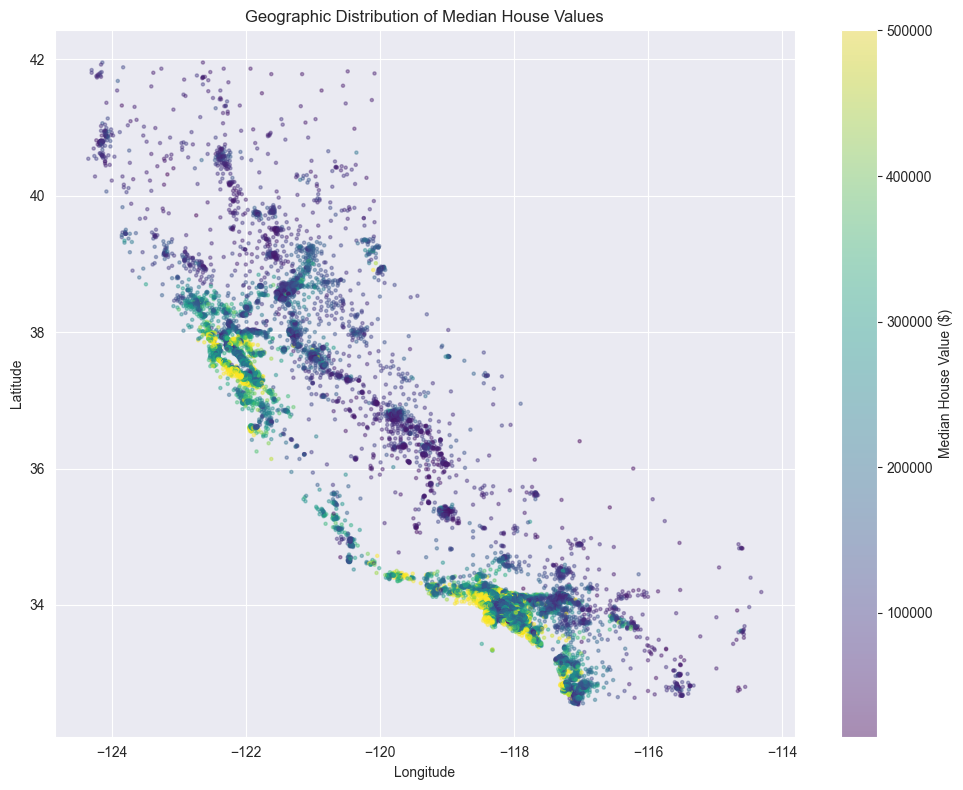

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot latitude and longitude coloured by house value to reveal geographic patterns
scatter = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    alpha=0.4,
    s=5
)

plt.colorbar(scatter, ax=ax, label="Median House Value ($)")
ax.set_title("Geographic Distribution of Median House Values")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

Each block group is plotted at its latitude and longitude, coloured by median house value.

- The data clearly traces the **coastline of California**, confirming full statewide coverage
- The **highest value areas** (brightest yellow) are concentrated along the coast, particularly around the **San Francisco Bay Area** (latitude ~37–38) and the **Los Angeles/San Diego region** (latitude ~33–34)
- **Inland areas** are predominantly darker, indicating lower house values
- This spatial pattern confirms that **geographic location is a strong predictor** of house value, beyond what `ocean_proximity` alone captures

### 4.7 Median House Value by Ocean Proximity

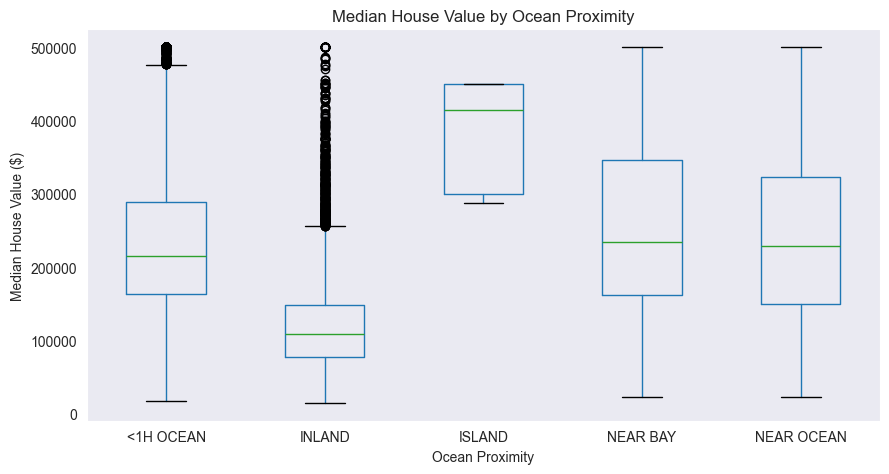

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

# Box plot to compare house value distributions across ocean proximity categories
df.boxplot(column="median_house_value", by="ocean_proximity", ax=ax, grid=False)

ax.set_title("Median House Value by Ocean Proximity")
ax.set_xlabel("Ocean Proximity")
ax.set_ylabel("Median House Value ($)")
plt.suptitle("")  # suppress the default pandas suptitle

plt.tight_layout()
plt.show()

Box plots compare the `median_house_value` distribution across each ocean proximity category.

- **`ISLAND`** shows the highest median, but with only 5 records this result is not statistically meaningful
- **`NEAR BAY`** and **`NEAR OCEAN`** have similar medians of around **`$230,000` to `$240,000`**
- **`1H OCEAN`** has a comparable median to the coastal categories but a wider spread, reflecting the diversity within this large group
- **`INLAND`** has clearly the **lowest median (~$120,000)** and the narrowest range, confirming that distance from the coast is associated with lower house values
- The `INLAND` category contains a large number of high-end outliers, suggesting a subset of unexpectedly expensive inland properties

## 5. Outlier Detection

Outlier detection is carried out to identify and quantify extreme values that may distort statistical analysis and model training. The **IQR (Interquartile Range)** method is used as a standard non-parametric approach.

### 5.1 IQR-Based Outlier Detection

In [18]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count rows outside the IQR bounds
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary[col] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(df) * 100, 2)
    }

In [19]:
outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Summary (IQR method):")
display(outlier_df)

Outlier Summary (IQR method):


,lower_bound,upper_bound,n_outliers,pct_outliers
longitude,-127.485000,-112.325000,0.0,0.00
latitude,28.260000,43.380000,0.0,0.00
housing_median_age,-10.500000,65.500000,0.0,0.00
total_rooms,-1102.625000,5698.375000,1287.0,6.24
total_bedrooms,-230.500000,1173.500000,1271.0,6.16
population,-620.000000,3132.000000,1196.0,5.79
households,-207.500000,1092.500000,1220.0,5.91
median_income,-0.706375,8.013025,681.0,3.30
median_house_value,-98087.500000,482412.500000,1071.0,5.19


The IQR method flags any value below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` as an outlier. Results show:

- **`total_rooms`, `total_bedrooms`, `population`, `households`**: Each has around **6% outliers**, consistent with the heavy right skew observed in their distributions
- **`median_house_value`**: **5.19% of values** fall above the upper IQR bound, partly driven by the artificial $500,001 cap
- **`median_income`**: Has **3.3% outliers**, representing a small number of very high-income block groups
- **`longitude`, `latitude`, `housing_median_age`**: No outliers detected, as these features are naturally bounded by geography and the data cap respectively

### 5.2 Box Plots for Outlier Visualisation

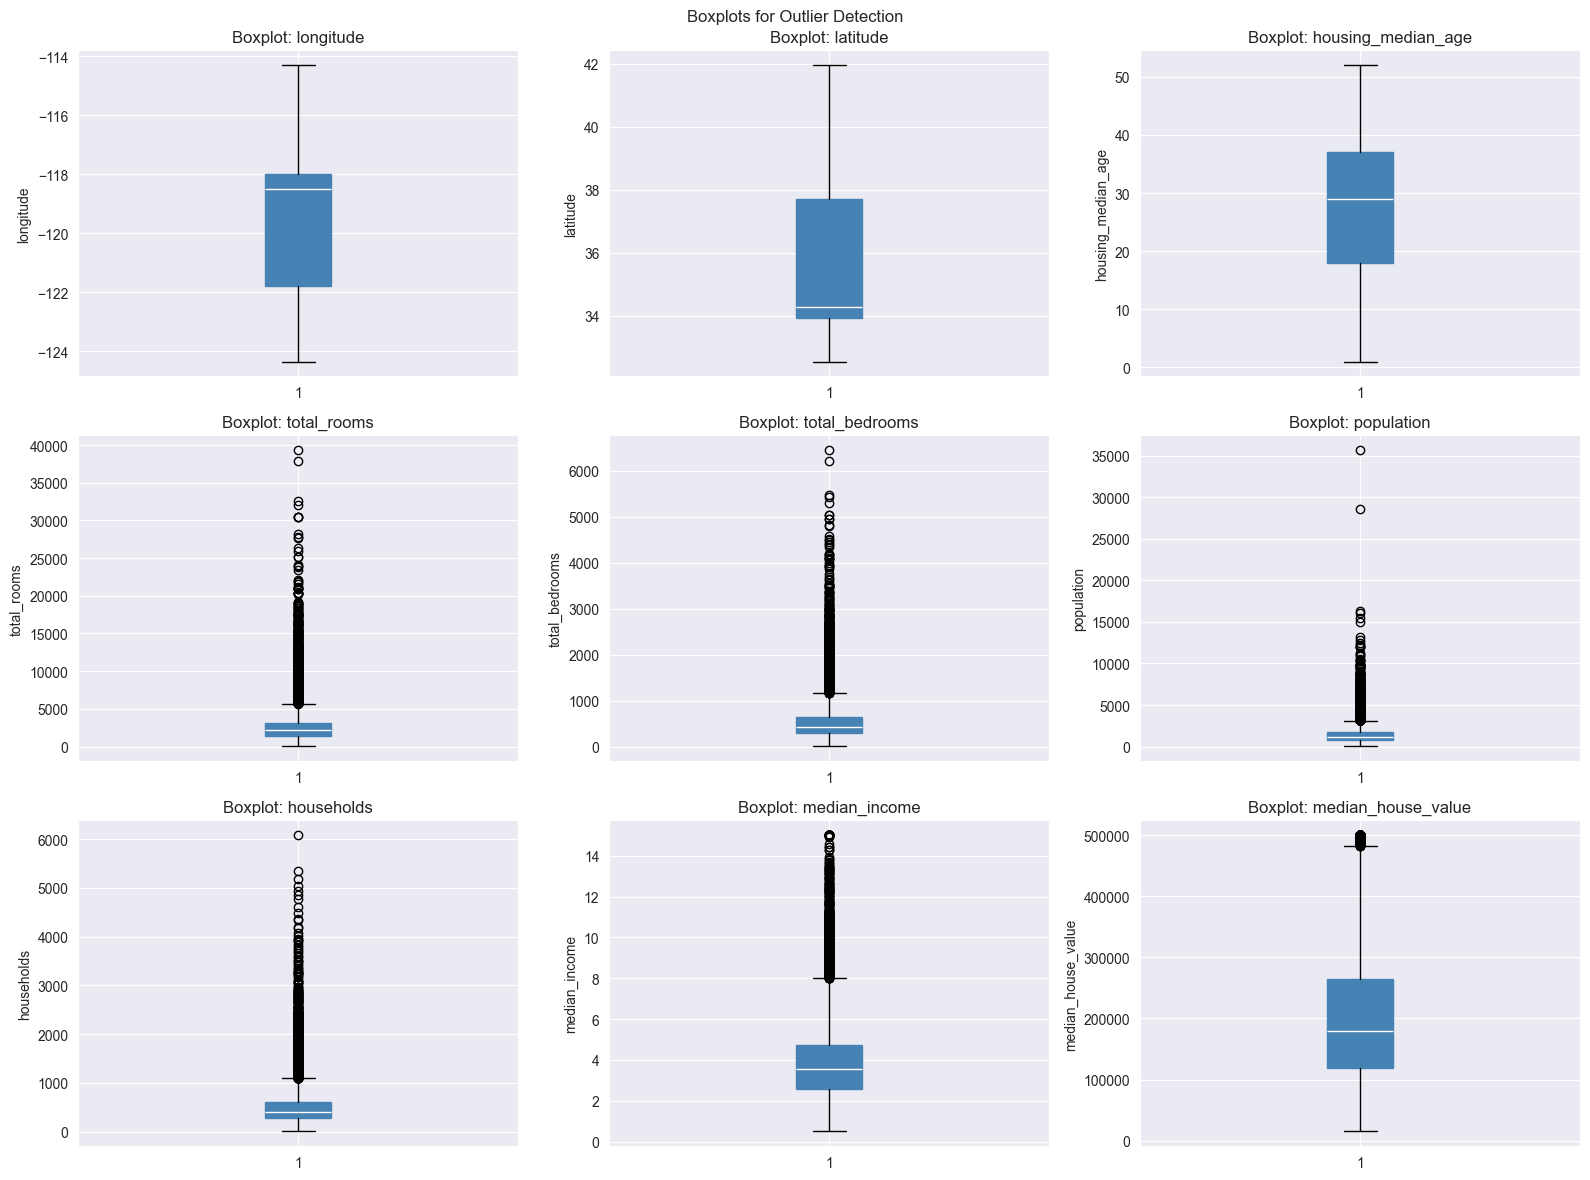

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", color="steelblue"),
                    medianprops=dict(color="white"))
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_ylabel(col)

plt.suptitle("Boxplots for Outlier Detection")
plt.tight_layout()
plt.show()

The 3×3 grid of box plots provides a visual confirmation of the IQR analysis.

- **`longitude`, `latitude`, `housing_median_age`**: Clean distributions with no outlier points visible
- **`total_rooms`, `total_bedrooms`, `population`, `households`**: All show **dense clouds of outlier points** above the upper whisker, consistent with the heavily right-skewed distributions seen earlier
- **`median_income`**: A moderate number of high-end outlier points, with values extending up to ~15
- **`median_house_value`**: Outliers are present at the upper end, with the distribution cut off sharply at $500,001

### 5.3 Capping Extreme Outliers (Optional Preprocessing Step)

In [21]:
# Note the hard cap at 500001 for median_house_value visible in describe()
# This is a known data artefact worth flagging in the paper
capped_count = (df["median_house_value"] == 500001.0).sum()
print(f"Rows where median_house_value is capped at 500001: {capped_count}")
print(f"This represents {round(capped_count / len(df) * 100, 2)}% of the dataset")

Rows where median_house_value is capped at 500001: 965
This represents 4.68% of the dataset


The analysis confirms that **965 records (4.68%)** have a `median_house_value` of exactly $500,001, which is a known artefact of data collection rather than a genuine house value. This is a significant proportion of the dataset and has several implications:

- Any regression model trained on this data will likely **underestimate** the value of high-end properties since the true ceiling is unknown
- This cap also artificially compresses the variance at the upper end, which may **inflate model performance metrics** for high-value predictions
- It is recommended to either **remove these capped records** or treat them as a separate category when evaluating model performance

## 6. Data Cleaning

Before feature engineering and modelling, the dataset is cleaned to handle missing values and flag known data quality issues.

### 6.1 Missing Values

Missing Value Summary
                Missing Count  Missing (%)
total_bedrooms            207          1.0


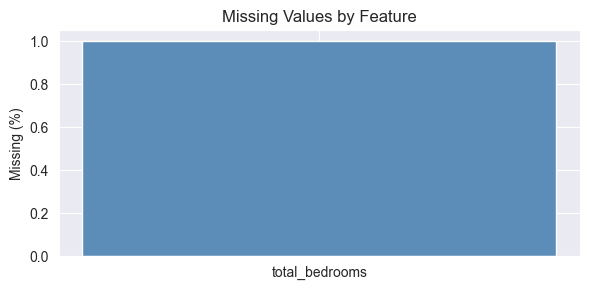

In [22]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing (%)": missing_pct
})

# Only show columns that actually have missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]
print("Missing Value Summary")
print(missing_summary)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(missing_summary.index, missing_summary["Missing (%)"], color="#5B8DB8")
ax.set_ylabel("Missing (%)")
ax.set_title("Missing Values by Feature")
plt.tight_layout()
plt.show()

Only `total_bedrooms` contains missing values, with **207 null entries (1.0%)** of the dataset. This is a small proportion but must be resolved before modelling. The bar chart confirms it is the only affected feature.

### 6.2 Imputing Missing Values

In [23]:
median_bedrooms = df["total_bedrooms"].median()
print(f"Median value of total_bedrooms: {median_bedrooms}")

# Fill missing values with the median to avoid skew from the mean
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")
print("All missing values resolved.")

Median value of total_bedrooms: 435.0

Missing values after imputation: 0
All missing values resolved.


Missing values in `total_bedrooms` are filled using **median imputation**. The median is preferred over the mean here because the feature is right-skewed, meaning the mean would be pulled upward by extreme values and would not be representative of a typical block group. After imputation, the dataset is fully complete with no remaining nulls.

### 6.3 Flagging Capped Target Values

In [24]:
capped_count = (df["median_house_value"] == 500001).sum()
capped_pct = (capped_count / len(df) * 100).round(2)

print(f"Rows with capped value ($500,001): {capped_count} ({capped_pct}% of dataset)")

# Add a flag column to track capped records without removing them
df["is_capped"] = df["median_house_value"] == 500001

Rows with capped value ($500,001): 965 (4.68% of dataset)


A binary flag column `is_capped` is added to mark the 965 records where `median_house_value` hits the artificial ceiling of $500,001. Rather than removing these rows, they are retained and flagged so their effect on model performance can be tracked separately. This is important because predictions for these records will systematically underestimate the true house value.

## 7. Feature Engineering

Raw features are transformed and new features are constructed to improve the signal available to machine learning models.

### 7.1 Creating New Features

In [25]:
# Ratio features capture density information that raw counts cannot
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("Shape after new features:", df.shape)

display(df[['rooms_per_household',
          'bedrooms_per_room',
          'population_per_household']].describe())

Shape after new features: (20640, 14)


,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


Three ratio features are engineered to capture information that the raw counts cannot:

- **`rooms_per_household`**: Measures how spacious a district is on average. A higher value suggests larger homes relative to the number of households
- **`bedrooms_per_room`**: Captures the bedroom density of properties. A lower value generally indicates more living space per bedroom
- **`population_per_household`**: Reflects average household size. Very high values (max 1243) indicate extreme outliers likely caused by unusual block groupings such as dormitories or care facilities

These derived features address the multicollinearity issue identified in the heatmap, where `total_rooms`, `total_bedrooms`, `population` and `households` were all measuring similar things.

### 7.2 Log Transformation of Skewed Features

Log transformations applied successfully!
Shape is now: (20640, 18)


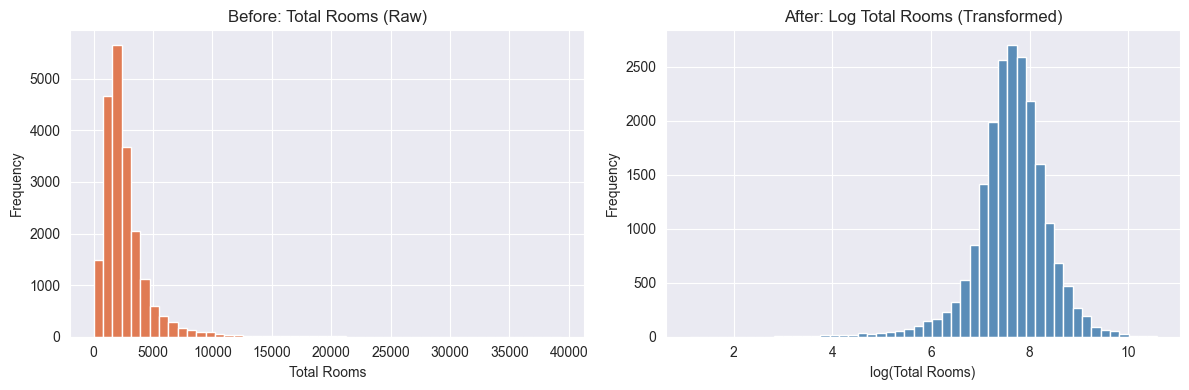

In [26]:
# np.log1p computes log(x + 1) to safely handle zero values
# Original columns are kept alongside the new log_ versions
df['log_total_rooms'] = np.log1p(df['total_rooms'])
df['log_total_bedrooms'] = np.log1p(df['total_bedrooms'])
df['log_population'] = np.log1p(df['population'])
df['log_households'] = np.log1p(df['households'])

print("Log transformations applied successfully!")
print("Shape is now:", df.shape)

# Before and after comparison for total_rooms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['total_rooms'], bins=50, color="#E07B54", edgecolor="white")
axes[0].set_title('Before: Total Rooms (Raw)')
axes[0].set_xlabel('Total Rooms')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['log_total_rooms'], bins=50, color="#5B8DB8", edgecolor="white")
axes[1].set_title('After: Log Total Rooms (Transformed)')
axes[1].set_xlabel('log(Total Rooms)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [27]:
# Print skewness before and after for all 4 features
print("\nSkewness Before and After Log Transformation")
print(f"total_rooms      — Before: {df['total_rooms'].skew():.2f}   After: {df['log_total_rooms'].skew():.2f}")
print(f"total_bedrooms   — Before: {df['total_bedrooms'].skew():.2f}   After: {df['log_total_bedrooms'].skew():.2f}")
print(f"population       — Before: {df['population'].skew():.2f}   After: {df['log_population'].skew():.2f}")
print(f"households       — Before: {df['households'].skew():.2f}   After: {df['log_households'].skew():.2f}")


Skewness Before and After Log Transformation
total_rooms      — Before: 4.15   After: -1.08
total_bedrooms   — Before: 3.48   After: -1.00
population       — Before: 4.94   After: -1.04
households       — Before: 3.41   After: -1.05


Four heavily skewed features are log-transformed using `np.log1p()` (which computes log(x + 1) to safely handle zero values). The before/after skewness values confirm the transformation is effective:

- All four features had skewness values **above 3**, indicating severe right skew
- After transformation, skewness values fall to approximately **-1.0**, indicating near-symmetric distributions
- `log1p` was chosen over a square root transformation as it produced skewness closer to 0
- Original columns are preserved alongside the new `log_` versions so both can be evaluated during modelling


### 7.3 Encoding ocean_proximity

In [28]:
# One-hot encoding converts the categorical column into binary 0/1 columns
# drop_first=True removes <1H OCEAN as the reference category
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    print("Encoding applied successfully!")
else:
    print("Already encoded — skipping!")

ocean_cols = [col for col in df.columns if 'ocean' in col]
print("\nCount of 1s in each encoded column")
print(df[ocean_cols].sum())

Encoding applied successfully!

Count of 1s in each encoded column
ocean_proximity_INLAND        6551
ocean_proximity_ISLAND           5
ocean_proximity_NEAR BAY      2290
ocean_proximity_NEAR OCEAN    2658
dtype: int64


### 7.4 Feature Scaling

In [29]:
# These are the continuous features that need scaling
# The target variable is excluded so predictions remain in dollar amounts
features_to_scale = [
    'housing_median_age',
    'median_income',
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'log_total_rooms',
    'log_total_bedrooms',
    'log_population',
    'log_households'
]

# fit_transform learns the mean and std then scales in one step
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\nSample of scaled features (first 3 rows):")
display(df[features_to_scale].head(3))

print("\nMean of scaled features (should all be ~0):")
display(df[features_to_scale].mean())

print("\nStd of scaled features (should all be ~1):")
display(df[features_to_scale].std())


Sample of scaled features (first 3 rows):


,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households
0,0.982143,2.344766,0.628559,-1.029988,-0.049597,-1.131133,-1.642192,-1.694943,-1.569395
1,-0.607019,2.332238,0.327041,-0.888897,-0.092512,1.651357,1.320043,1.030337,1.449251
2,1.856182,1.782699,1.155620,-1.291686,-0.025843,-0.450310,-1.110094,-1.109604,-1.104849



Mean of scaled features (should all be ~0):


housing_median_age          5.508083e-18
median_income               6.609700e-17
rooms_per_household         6.609700e-17
bedrooms_per_room           1.542263e-16
population_per_household    3.442552e-18
log_total_rooms            -1.039651e-15
log_total_bedrooms          9.088337e-17
log_population             -9.528984e-16
log_households              7.683776e-16
dtype: float64


Std of scaled features (should all be ~1):


housing_median_age          1.000024
median_income               1.000024
rooms_per_household         1.000024
bedrooms_per_room           1.000024
population_per_household    1.000024
log_total_rooms             1.000024
log_total_bedrooms          1.000024
log_population              1.000024
log_households              1.000024
dtype: float64

## 8. Modelling

### 8.1 Train/Test Split

In [30]:
# Drop the target and the capped flag from features
# is_capped is a data quality label, not a real predictor
X = df.drop(columns=['median_house_value', 'is_capped'])
y = df['median_house_value']

print("Data Preparation")
print("X shape (features):", X.shape)
print("y shape (target):", y.shape)
print("\nFeatures used for prediction:")
print(X.columns.tolist())

# 80/20 split, random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nSplit Summary")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Total:        {X_train.shape[0] + X_test.shape[0]} rows")

Data Preparation
X shape (features): (20640, 19)
y shape (target): (20640,)

Features used for prediction:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'log_total_rooms', 'log_total_bedrooms', 'log_population', 'log_households', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

Split Summary
Training set: 16512 rows
Test set:     4128 rows
Total:        20640 rows


### 8.2 Linear Regression

Linear Regression model trained!

Linear Regression Results
RMSE: $72,237
R²:   0.602


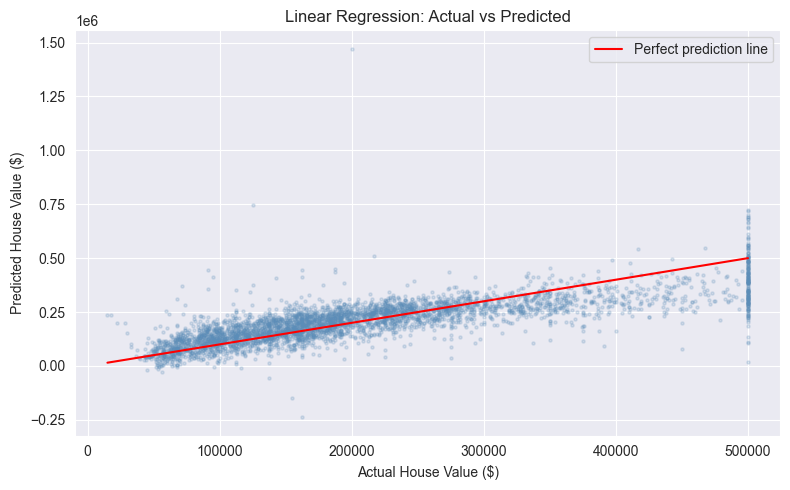

In [31]:
# Baseline model — assumes linear relationships between features and target
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained!")

lr_predictions = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("\nLinear Regression Results")
print(f"RMSE: ${lr_rmse:,.0f}")
print(f"R²:   {lr_r2:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, lr_predictions, alpha=0.2, s=5, color="#5B8DB8")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=1.5, label='Perfect prediction line')
ax.set_xlabel("Actual House Value ($)")
ax.set_ylabel("Predicted House Value ($)")
ax.set_title("Linear Regression: Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Decision Tree

Decision Tree model trained!

Decision Tree Results
RMSE: $64,175
R²:   0.686

On average the model's predictions are $64,175 away from the real price.
The model explains 68.6% of the variation in house prices.


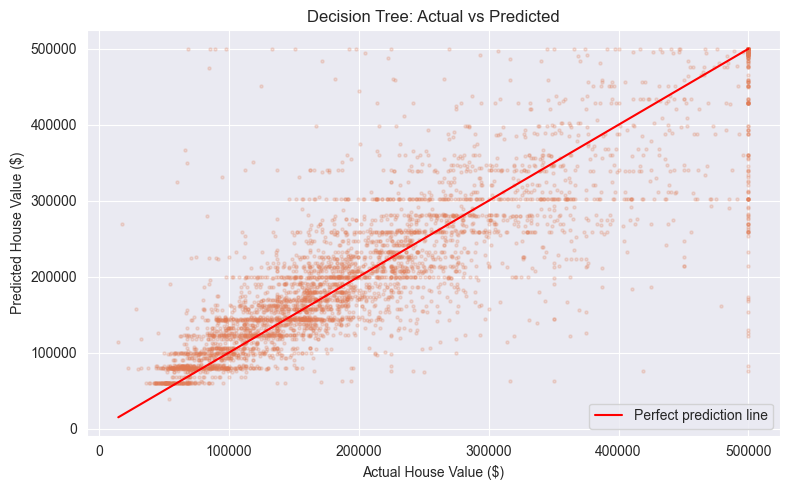

In [32]:
# max_depth=10 prevents the tree from memorising training data (overfitting)
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree model trained!")

dt_predictions = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("\nDecision Tree Results")
print(f"RMSE: ${dt_rmse:,.0f}")
print(f"R²:   {dt_r2:.3f}")
print(f"\nOn average the model's predictions are ${dt_rmse:,.0f} away from the real price.")
print(f"The model explains {dt_r2*100:.1f}% of the variation in house prices.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, dt_predictions, alpha=0.2, s=5, color="#E07B54")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=1.5, label='Perfect prediction line')
ax.set_xlabel("Actual House Value ($)")
ax.set_ylabel("Predicted House Value ($)")
ax.set_title("Decision Tree: Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()

### 8.4 Random Forest

Random Forest model trained!

Random Forest Results
RMSE: $50,406
R²:   0.806


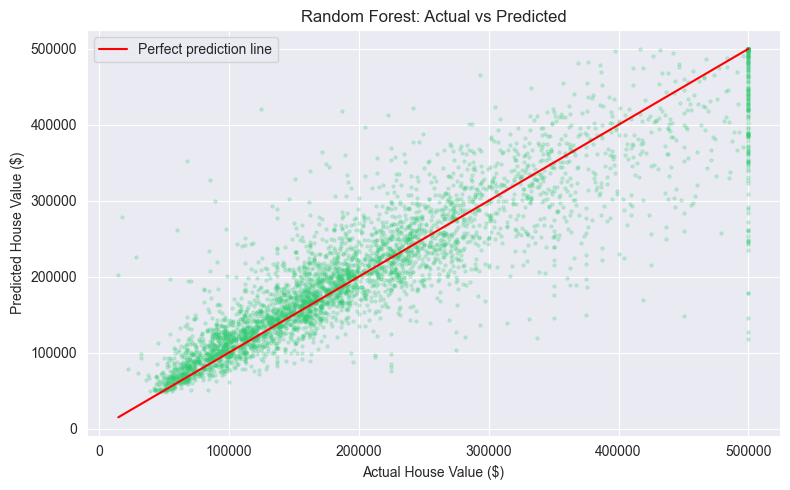

In [33]:
# Builds 100 decision trees on random subsets and averages predictions
# This reduces variance compared to a single decision tree
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest model trained!")

rf_predictions = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("\nRandom Forest Results")
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"R²:   {rf_r2:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, rf_predictions, alpha=0.2, s=5, color="#2ECC71")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=1.5, label='Perfect prediction line')
ax.set_xlabel("Actual House Value ($)")
ax.set_ylabel("Predicted House Value ($)")
ax.set_title("Random Forest: Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()

### 8.5 Model Comparison

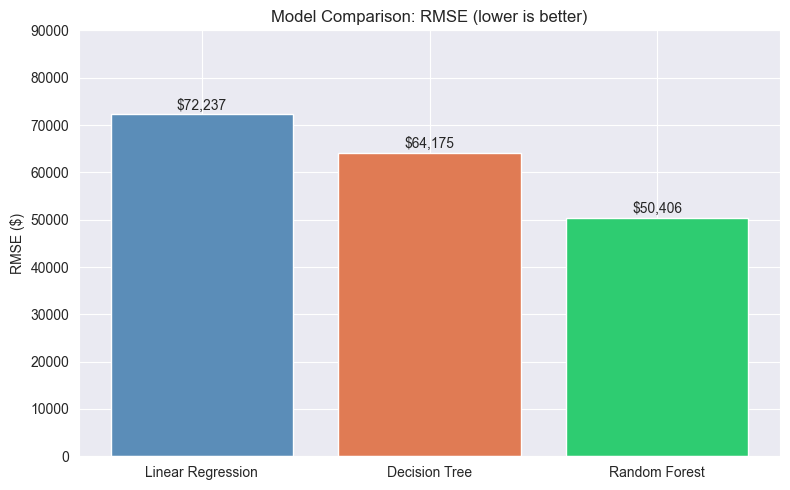

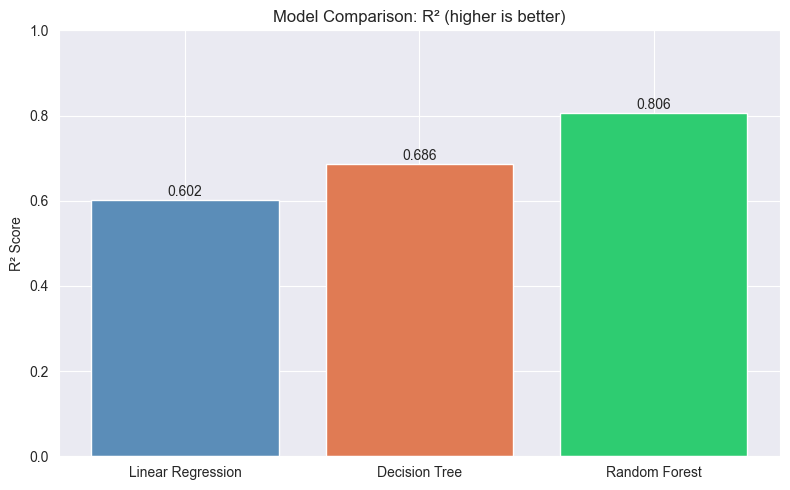

In [34]:
models      = ['Linear Regression', 'Decision Tree', 'Random Forest']
rmse_scores = [lr_rmse, dt_rmse, rf_rmse]
r2_scores   = [lr_r2, dt_r2, rf_r2]

# RMSE comparison — lower is better
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, rmse_scores,
              color=["#5B8DB8", "#E07B54", "#2ECC71"],
              edgecolor="white")
ax.set_title("Model Comparison: RMSE (lower is better)")
ax.set_ylabel("RMSE ($)")
ax.set_ylim(0, 90000)

for bar, value in zip(bars, rmse_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1000,
            f"${value:,.0f}",
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# R² comparison — higher is better
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores,
              color=["#5B8DB8", "#E07B54", "#2ECC71"],
              edgecolor="white")
ax.set_title("Model Comparison: R² (higher is better)")
ax.set_ylabel("R² Score")
ax.set_ylim(0, 1.0)

for bar, value in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{value:.3f}",
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
print("Model Comparison Summary")
for model, rmse, r2 in zip(models, rmse_scores, r2_scores):
    print(f"{model}: RMSE=${rmse:,.0f}  R²={r2:.3f}")

Model Comparison Summary
Linear Regression: RMSE=$72,237  R²=0.602
Decision Tree: RMSE=$64,175  R²=0.686
Random Forest: RMSE=$50,406  R²=0.806


## 9. Model Evaluation

### 9.1 Feature Importance

Feature Importance Scores
                   Feature  Importance
             median_income      0.4811
    ocean_proximity_INLAND      0.1375
  population_per_household      0.1210
                 longitude      0.0576
                  latitude      0.0561
        housing_median_age      0.0438
       rooms_per_household      0.0255
         bedrooms_per_room      0.0236
               total_rooms      0.0068
           log_total_rooms      0.0068
        log_total_bedrooms      0.0066
            total_bedrooms      0.0064
            log_population      0.0062
                population      0.0062
            log_households      0.0059
                households      0.0056
ocean_proximity_NEAR OCEAN      0.0024
  ocean_proximity_NEAR BAY      0.0009
    ocean_proximity_ISLAND      0.0001


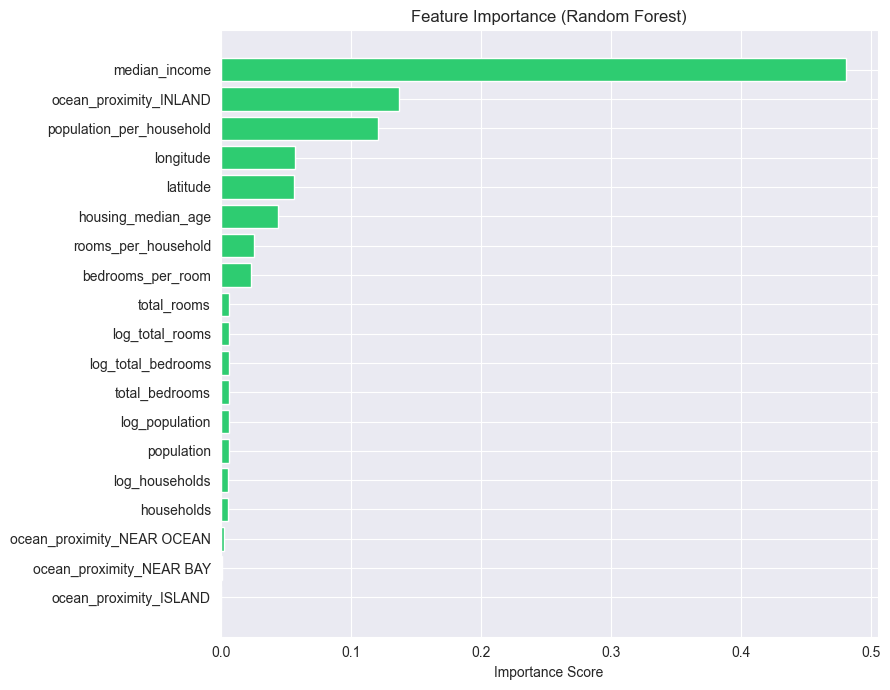

In [36]:
# Feature importance scores show how much each feature contributed
# across all 100 trees in the Random Forest
feature_names = X_train.columns.tolist()
importance_scores = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending=False)

print("Feature Importance Scores")
print(importance_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df['Feature'],
        importance_df['Importance'],
        color="#2ECC71", edgecolor="white")
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance (Random Forest)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 9.2 Residuals Analysis

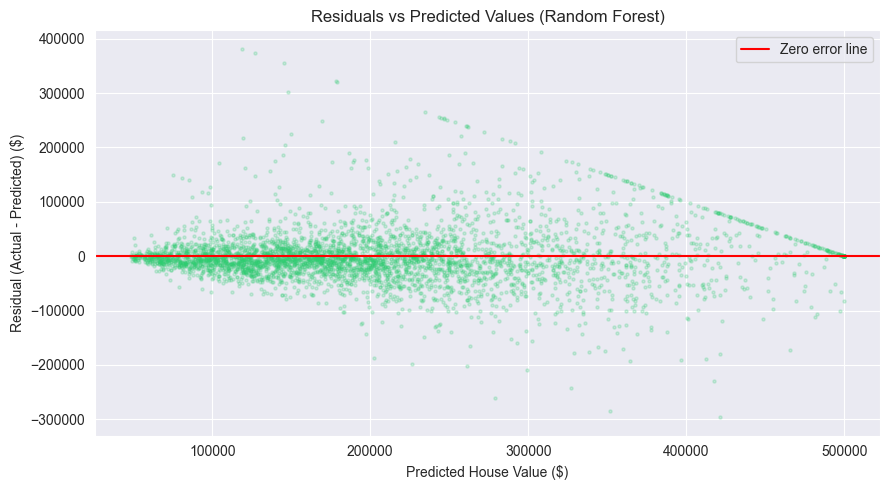

In [37]:
# Residuals = actual minus predicted
# A well-behaved model has residuals scattered randomly around zero
residuals = y_test - rf_predictions

# Residuals vs predicted values
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(rf_predictions, residuals, alpha=0.2, s=5, color="#2ECC71")
ax.axhline(y=0, color='red', linewidth=1.5, label='Zero error line')
ax.set_xlabel("Predicted House Value ($)")
ax.set_ylabel("Residual (Actual - Predicted) ($)")
ax.set_title("Residuals vs Predicted Values (Random Forest)")
ax.legend()
plt.tight_layout()
plt.show()

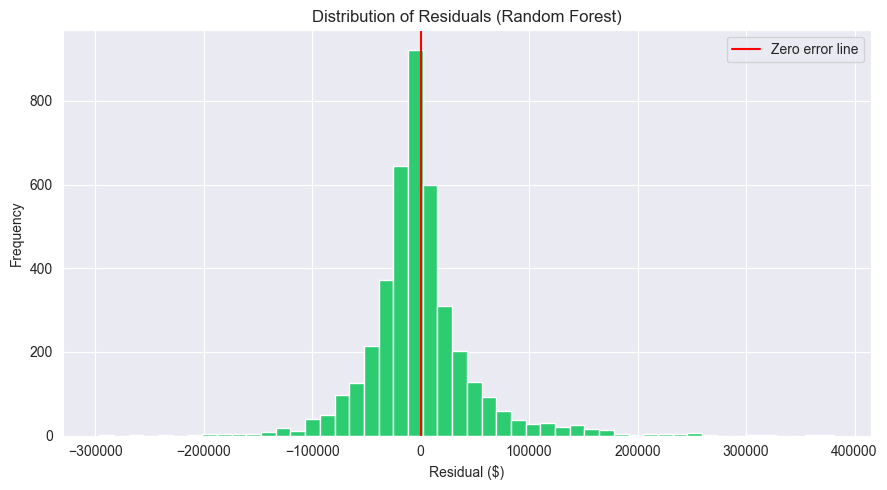

Residual Summary
Mean residual:        $-1,296
Std of residuals:     $50,395
Max over-prediction:  $-296,235
Max under-prediction: $381,421


In [38]:
# Distribution of residuals
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=50, color="#2ECC71", edgecolor="white")
ax.axvline(x=0, color='red', linewidth=1.5, label='Zero error line')
ax.set_xlabel("Residual ($)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Residuals (Random Forest)")
ax.legend()
plt.tight_layout()
plt.show()

print("Residual Summary")
print(f"Mean residual:        ${residuals.mean():,.0f}")
print(f"Std of residuals:     ${residuals.std():,.0f}")
print(f"Max over-prediction:  ${residuals.min():,.0f}")
print(f"Max under-prediction: ${residuals.max():,.0f}")